# Session 14: MCP-Powered HackerNews Post Summarizer

## Building a LangGraph Agent with GitHub MCP Tools, HackerNews API Tools, and Memory

## Learning Objectives:

- **Ingest MCP servers as LangGraph tools** using `langchain-mcp-adapters` to connect to the GitHub MCP Server and use its tools programmatically
- **Wrap the X (Twitter) API as a LangChain tool** using the `@tool` decorator so a LangGraph agent can search and retrieve public posts
- **Build a LangGraph agent with memory** that combines MCP-sourced tools and custom tools, using `MemorySaver` for short-term conversational memory
- **Orchestrate a full workflow through the agent** — search X posts, generate summaries, create a GitHub repo, commit files, branch, and open a PR — all via natural language

## Overview

In this notebook, you will build a **LangGraph ReAct agent** that has access to two categories of tools:

1. **GitHub MCP tools** — loaded from the official GitHub MCP Server via `langchain-mcp-adapters`. These replace manual `git` commands with tool calls the agent can invoke (create repos, commit files, create branches, open PRs).
2. **HackerNews API tools** — custom Python functions wrapped with the `@tool` decorator that call the HackerNews API  directly to search and retrieve posts.

The agent uses **`MemorySaver`** for short-term memory so it can maintain context across multi-step workflows within a conversation thread.

There will be one breakout room with two phases:

- 🤝 Phase 1: Setup, Tools & Agent Construction
  - Task 1: Dependencies & Environment
  - Task 2: HackerNews API as LangChain Tools
  - Task 3: Connect to GitHub MCP Server & Load Tools
  - Task 4: Build the LangGraph Agent with Memory
  - Task 5: Test the Agent — Search & Summarize HackerNews Posts
  - Activity #1: Extend the Agent with a Custom HackerNews API Tool
- 🤝 Phase 2: MCP Workflow Through the Agent
  - Task 6: Create a GitHub Repository
  - Task 7: Commit the Summary
  - Task 8: Create a Feature Branch & Add Metadata
  - Task 9: Open a Pull Request
  - Task 10: Commit the HackerNews API Script
  - Task 11: Update the README
  - Activity #1: Multi-Account Comparison Pipeline

---

# 🤝 Breakout Room 
## Setup, Tools & Agent Construction

## Task 1: Dependencies & Environment

We need:
- `langchain-mcp-adapters` to connect to MCP servers and convert their tools into LangChain tools
- `langgraph` for our agent graph with memory
- `langchain-openai` for our LLM
- `requests` for the X API calls
- `nest-asyncio` for async MCP operations inside Jupyter

> NOTE: Create a `.env` file in this directory with `OPENAI_API_KEY`, and `GITHUB_PAT` before running.
> 
> Setup references:
> - GitHub fine-grained PAT guide: [Creating a personal access token](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens#creating-a-fine-grained-personal-access-token)



In [ ]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

if not os.environ.get("GITHUB_PAT"):
    os.environ["GITHUB_PAT"] = getpass.getpass("Enter your GitHub PAT:")

In [3]:
import nest_asyncio
nest_asyncio.apply()  # Required for async operations in Jupyter

### Getting Your Credentials

**GitHub PAT (fine-grained):**
1. Open [GitHub Personal Access Tokens (fine-grained)](https://github.com/settings/personal-access-tokens/new).
2. Follow [GitHub's PAT setup guide](https://docs.github.com/en/authentication/keeping-your-account-and-data-secure/managing-your-personal-access-tokens#creating-a-fine-grained-personal-access-token).
3. Set repository permissions to at least:
   - `Contents`: Read and write
   - `Pull requests`: Read and write
   - `Metadata`: Read-only


In [4]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

# Test the connection
response = llm.invoke("Say 'MCP agent ready!' in exactly those words.")
print(response.content)

MCP agent ready!


## Task 2: X API as LangChain Tools

Instead of relying on a community-built MCP server for X, we'll call the **X API v2** directly and wrap our functions with the `@tool` decorator. This makes them available to our LangGraph agent as callable tools — just like the MCP tools will be.

This is a key architectural decision: **not everything needs to be an MCP server**. Wrapping a simple API call as a `@tool` is often simpler and more transparent.

**📚 Documentation:**
- [LangChain Tools Conceptual Guide](https://python.langchain.com/docs/concepts/tools/)
- [X API v2 Documentation](https://developer.x.com/en/docs/x-api)

In [16]:
import requests
import json
from langchain_core.tools import tool


@tool
def search_hn_stories(query: str, max_results: int = 20) -> str:
    """Search Hacker News stories by topic/keyword.
    Returns recent stories from the last 10 days matching the query.

    Args:
        query: The search query (e.g., 'AI safety', '#machinelearning', 'from:AndrewYNg')
        max_results: Number of results to return (10-100, default 20)
    """
    response = requests.get(
    "https://hn.algolia.com/api/v1/search",
    params={
        "query": query,
        "hitsPerPage": max_results,
        "tags": "story"   # only stories, not comments
    }
    )
    data = response.json()
    if not data.get("hits"):
        return "No stories found for this query."
    result_lines = [f"Found {len(data['hits'])} stories:\n"]
    for story in data['hits']:
        text = story.get("story_text", "") or story.get("title", "")
        if len(text) <= 350:  # short enough to use in full
            snippet = text
        else:
            snippet = text[:150] + " ...[truncated]... " + text[-200:]
        result_lines.append(
            f"[{story['created_at'][:10]}] "
            f"{story['title']} ({story.get('url', '—')}) "
            f"Score: {story['points']} | Comments: {story['num_comments']}"
            f"\n  {snippet}"
        )
    return "\n\n".join(result_lines)




hn_tools = [search_hn_stories]

print(f"Created {len(hn_tools)} Hacker News tools: {[t.name for t in hn_tools]}")

Created 1 Hacker News tools: ['search_hn_stories']


Let's verify our HackerNews API tools work before wiring them into the agent:

In [6]:
# Quick test — fetch recent posts
result = search_hn_stories.invoke({"query": "AI safety", "max_results": 3})
print(result[:1000])

Found 3 stories:


[2025-02-12] US and UK refuse to sign AI safety declaration at summit (https://arstechnica.com/ai/2025/02/us-and-uk-refuse-to-sign-ai-safety-declaration-at-summit/) Score: 447 | Comments: 796
  US and UK refuse to sign AI safety declaration at summit

[2024-01-16] Many AI safety orgs have tried to criminalize currently-existing open-source AI (https://1a3orn.com/sub/machine-learning-bans.html) Score: 385 | Comments: 389
  Many AI safety orgs have tried to criminalize currently-existing open-source AI

[2023-11-23] After OpenAI's blowup, it seems pretty clear that 'AI safety' isn't a real thing (https://gizmodo.com/ai-safety-openai-sam-altman-ouster-back-microsoft-1851038439) Score: 295 | Comments: 370
  After OpenAI's blowup, it seems pretty clear that 'AI safety' isn't a real thing


## Task 3: Connect to GitHub MCP Server & Load Tools

Now we'll connect to the **GitHub MCP Server** — an official, GitHub-maintained MCP server that gives agents the ability to manage repositories, issues, pull requests, and more.

We use `langchain-mcp-adapters` to:
1. Connect to the remote GitHub MCP server over HTTP
2. Automatically convert all MCP tools into LangChain-compatible tools

This is the key MCP integration point — instead of writing custom GitHub API wrappers, we get a full set of tools for free just by connecting to the MCP server.

**📚 Documentation:**
- [langchain-mcp-adapters](https://github.com/langchain-ai/langchain-mcp-adapters)
- [GitHub MCP Server](https://github.com/github/github-mcp-server)
- [Model Context Protocol Specification](https://modelcontextprotocol.io/)

In [7]:
from langchain_mcp_adapters.client import MultiServerMCPClient

# Connect to the GitHub MCP server using Streamable HTTP transport
# The server exposes GitHub operations as MCP tools that our agent can call
mcp_client = MultiServerMCPClient(
    {
        "github": {
            "transport": "http",
            "url": "https://api.githubcopilot.com/mcp/",
            "headers": {
                "Authorization": f"Bearer {os.environ['GITHUB_PAT']}",
            },
        }
    }
)

# Load all tools from the MCP server
github_mcp_tools = await mcp_client.get_tools()

print(f"Loaded {len(github_mcp_tools)} GitHub MCP tools:\n")
for t in github_mcp_tools:
    print(f"  - {t.name}: {t.description[:80]}...")

Loaded 41 GitHub MCP tools:

  - add_comment_to_pending_review: Add review comment to the requester's latest pending pull request review. A pend...
  - add_issue_comment: Add a comment to a specific issue in a GitHub repository. Use this tool to add c...
  - add_reply_to_pull_request_comment: Add a reply to an existing pull request comment. This creates a new comment that...
  - create_branch: Create a new branch in a GitHub repository...
  - create_or_update_file: Create or update a single file in a GitHub repository. 
If updating, you should ...
  - create_pull_request: Create a new pull request in a GitHub repository....
  - create_repository: Create a new GitHub repository in your account or specified organization...
  - delete_file: Delete a file from a GitHub repository...
  - fork_repository: Fork a GitHub repository to your account or specified organization...
  - get_commit: Get details for a commit from a GitHub repository...
  - get_file_contents: Get the contents of a file 

### Key GitHub MCP Tools

The MCP server exposes many tools, but the key ones we'll use are:

| MCP Tool | Replaces (Git CLI) | What It Does |
|---|---|---|
| `create_repository` | `git init` + GitHub UI | Creates a new repo on your account |
| `create_or_update_file` | `git add` + `git commit` + `git push` | Commits a file directly to a branch |
| `create_branch` | `git checkout -b` | Creates a new branch |
| `create_pull_request` | `gh pr create` | Opens a PR from one branch to another |
| `search_repositories` | `gh repo list` | Searches across your repos |
| `get_file_contents` | `git show` / `cat` | Reads a file from a repo |
| `list_commits` | `git log` | Shows commit history |

## Task 4: Build the LangGraph Agent with Memory

Now we combine **both tool sets** into a single LangGraph agent:
- **HackerNews API tools** — custom `@tool` functions for searching posts
- **GitHub MCP tools** — loaded from the MCP server via `langchain-mcp-adapters`

We add **`MemorySaver`** for short-term memory so the agent remembers context across the multi-step workflow (e.g., it fetches posts in one turn, summarizes them in the next, and commits the summary in a third).

The architecture follows the standard LangGraph ReAct pattern from Sessions 4-6:

```
┌─────────┐     ┌───────────┐
│  START   │────▶│   Agent   │◀──────────────┐
└─────────┘     │  (LLM +   │               │
                │   tools)  │               │
                └─────┬─────┘               │
                      │                     │
               has tool calls?              │
                /           \               │
              yes            no             │
              /               \             │
    ┌─────────────┐     ┌─────────┐        │
    │  Tool Node  │     │   END   │        │
    │ (X API +    │     └─────────┘        │
    │  GitHub MCP)│─────────────────────────┘
    └─────────────┘
```

**📚 Documentation:**
- [LangGraph ReAct Agent](https://langchain-ai.github.io/langgraph/tutorials/introduction/)
- [MemorySaver (Checkpointing)](https://langchain-ai.github.io/langgraph/concepts/persistence/)
- [ToolNode Prebuilt](https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.tool_node.ToolNode)

In [8]:
from typing import Annotated, Literal
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# Combine all tools: X API tools + GitHub MCP tools
all_tools = hn_tools + github_mcp_tools
print(f"Total tools available to agent: {len(all_tools)}")
print(f"  HackerNews API tools: {[t.name for t in hn_tools]}")
print(f"  GitHub MCP tools: {[t.name for t in github_mcp_tools]}")

Total tools available to agent: 42
  HackerNews API tools: ['search_hn_stories']
  GitHub MCP tools: ['add_comment_to_pending_review', 'add_issue_comment', 'add_reply_to_pull_request_comment', 'create_branch', 'create_or_update_file', 'create_pull_request', 'create_repository', 'delete_file', 'fork_repository', 'get_commit', 'get_file_contents', 'get_label', 'get_latest_release', 'get_me', 'get_release_by_tag', 'get_tag', 'get_team_members', 'get_teams', 'issue_read', 'issue_write', 'list_branches', 'list_commits', 'list_issue_types', 'list_issues', 'list_pull_requests', 'list_releases', 'list_tags', 'merge_pull_request', 'pull_request_read', 'pull_request_review_write', 'push_files', 'request_copilot_review', 'run_secret_scanning', 'search_code', 'search_issues', 'search_pull_requests', 'search_repositories', 'search_users', 'sub_issue_write', 'update_pull_request', 'update_pull_request_branch']


In [9]:
# Step 1: Define the Agent State
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


# Step 2: Define the system prompt
SYSTEM_PROMPT = """You are an AI assistant that can search HackerNews posts and manage GitHub repositories.

You have two categories of tools:
1. HackerNews API tools: search_hn_stories — for searching and retrieving HackerNews posts
2. GitHub MCP tools: for creating repos, committing files, creating branches, opening PRs, etc.

When asked to summarize posts, retrieve them first using the HackerNews API tools, then provide a structured
markdown summary with: Overview, Key Themes, Notable Posts, and Summary Statistics.

When asked to perform GitHub operations, use the appropriate GitHub MCP tool.
Always use the available tools when appropriate. Be concise in your responses."""


# Step 3: Bind tools to the LLM
llm_with_tools = llm.bind_tools(all_tools)


# Step 4: Define the agent node
def agent_node(state: AgentState):
    """The agent node — calls the LLM with the current conversation and available tools."""
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


# Step 5: Define the tool node
tool_node = ToolNode(all_tools, handle_tool_errors=True)


# Step 6: Define routing logic
def should_continue(state: AgentState) -> Literal["tools", "end"]:
    """Determine whether to call tools or end the conversation."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return "end"


# Step 7: Build the graph
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")

# Compile with MemorySaver for short-term memory across turns
checkpointer = MemorySaver()
agent = workflow.compile(checkpointer=checkpointer)

print("Agent compiled with memory and tools!")

Agent compiled with memory and tools!


Let's visualize the graph to confirm our architecture:

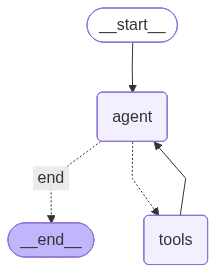

In [10]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

### Helper function for running the agent

We'll use a single `thread_id` throughout the notebook so the agent remembers previous interactions (short-term memory via the checkpointer).

In [11]:
# Use a consistent thread_id so the agent remembers context across all tasks
config = {"configurable": {"thread_id": "mcp-workflow-1"}}


async def ask_agent(user_message: str) -> str:
    """Send a message to the agent and return its final response."""
    response = await agent.ainvoke(
        {"messages": [HumanMessage(content=user_message)]},
        config,
    )
    return response["messages"][-1].content

## Task 5: Test the Agent — Search & Summarize X Posts

Let's put the agent through its paces. First, we'll ask it to search for posts and generate a summary. Because we're using `MemorySaver` with a consistent `thread_id`, the agent will remember the posts it found when we ask it to summarize them.

In [13]:
# Ask the agent to fetch stories related to OpenClaw — it will use the search_hn_stories tool
result = await ask_agent("Get recent stories related to OpenClaw on HackerNews.")
print(result[:1000])

Here are recent HackerNews stories related to OpenClaw:

1. Google restricting Google AI Pro/Ultra subscribers for using OpenClaw
   - Date: 2026-02-22
   - Score: 802 | Comments: 705
   - Link: https://discuss.ai.google.dev/t/account-restricted-without-warning-google-ai-ultra-oauth-via-openclaw/122778

2. OpenClaw – Moltbot Renamed Again
   - Date: 2026-01-30
   - Score: 667 | Comments: 382
   - Link: https://openclaw.ai/blog/introducing-openclaw

3. OpenClaw is what Apple intelligence should have been
   - Date: 2026-02-05
   - Score: 518 | Comments: 417
   - Link: https://www.jakequist.com/thoughts/openclaw-is-what-apple-intelligence-should-have-been

4. OpenClaw is changing my life
   - Date: 2026-02-08
   - Score: 340 | Comments: 513
   - Link: https://reorx.com/blog/openclaw-is-changing-my-life/

5. A sane but bull case on Clawdbot / OpenClaw
   - Date: 2026-02-03
   - Score: 303 | Comments: 482
   - Link: https://brandon.wang/2026/clawdbot

6. OpenClaw surpasses React to become 

In [14]:
# Ask the agent to summarize — it remembers the posts from the previous turn!
summary = await ask_agent(
    "Now summarize those posts into a structured markdown report with sections for: "
    "Overview, Key Themes, Notable Posts, and Summary Statistics. "
    "Format it so it can be saved directly as a summary.md file."
)
print(summary)

```markdown
# OpenClaw HackerNews Stories Summary

## Overview
OpenClaw has been a prominent topic on HackerNews recently, with discussions spanning its impact, comparisons to other technologies, and community projects built around it. The stories reflect a mix of user experiences, technical insights, and ecosystem developments. OpenClaw is noted for its rapid rise in popularity, even surpassing major projects like React in GitHub stars.

## Key Themes
- **User Impact and Experiences:** Several posts highlight how OpenClaw is changing users' lives and its potential as a transformative technology.
- **Community and Ecosystem Growth:** Projects like DenchClaw and Klaus demonstrate the expanding ecosystem built on OpenClaw.
- **Comparisons and Alternatives:** Discussions include comparisons to Apple intelligence and alternatives like Nanobot.
- **Controversies and Restrictions:** Google restricting AI Pro/Ultra subscribers for using OpenClaw indicates some friction with major platforms.
-

Save the summary locally for reference:

In [15]:
with open("summary.md", "w") as f:
    f.write(summary)

print("Summary saved to summary.md")

Summary saved to summary.md


### ❓ Question #1:



##### Answer:

*Your answer here*

### 🏗️ Activity #1: Extend the Agent with Custom Hacker News Tools

Your task is to add **two new Hacker News tools** and verify they work end-to-end.

1. **Create `get_top_stories`** — a tool that retrieves the current top stories from the Hacker News front page. Use the Firebase API:
   - `GET https://hacker-news.firebaseio.com/v0/topstories.json` to get story IDs
   - For each ID (limit to `max_results`), fetch `GET https://hacker-news.firebaseio.com/v0/item/{id}.json`
   - Filter for `type == "story"`, and format each with: date, title, score, comment count, and truncated text (first 150 chars + last 200 chars when the text is long)

2. **Create `get_ask_hn_by_topic`** — a tool that searches only Ask HN posts by topic. Use the Algolia API with `tags=ask_hn`:
   - `GET https://hn.algolia.com/api/v1/search` with params `query`, `tags="ask_hn"`, and `hitsPerPage`
   - Reuse the same output format as `search_hn_stories` (title, truncated text, score, comments, date)

3. **Rebuild the agent** — add both tools to `hn_tools` (or `x_api_tools`), re-combine with the GitHub MCP tools, re-bind tools to the LLM, and recompile the graph.

4. **Test the agent** by asking it to:
   - Fetch the current top 5 stories on HN and summarize what's trending
   - Search Ask HN for a topic of your choice (e.g., "career advice" or "Python") and compare those discussions with the top stories — what themes overlap?

> **HINT:** Extract a shared helper for truncating story text (first 150 + last 200 chars) so all three HN tools use the same logic.

In [17]:
### YOUR CODE HERE
from datetime import datetime, timezone

@tool
def get_top_stories(max_results: int = 5) -> str:
    """Retrieve the current top stories from the Hacker News front page."""
    url = "https://hacker-news.firebaseio.com/v0/topstories.json"
    response = requests.get(url)
    response.raise_for_status()
    story_ids = response.json()[:max_results]
    result_lines = []
    for story_id in story_ids:
        item_url = f"https://hacker-news.firebaseio.com/v0/item/{story_id}.json"
        item_response = requests.get(item_url)
        item_response.raise_for_status()
        item = item_response.json()
        if item.get("type") == "story":
            text = item.get("text", "") or item.get("title", "")
            if len(text) <= 350:
                snippet = text
            else:
                snippet = text[:150] + " ...[truncated]... " + text[-200:]
            date_str = datetime.fromtimestamp(item["time"], tz=timezone.utc).strftime("%Y-%m-%d")
            result_lines.append(
                f"[{date_str}] "
                f"{item['title']} ({item.get('url', '—')}) "
                f"Score: {item.get('score', 0)} | Comments: {len(item.get('kids', []))}"
                f"\n  {snippet}"
            )
    return "\n\n".join(result_lines)

@tool
def get_ask_hn_by_topic(query: str, max_results: int = 5) -> str:
    """Search Ask HN posts by topic."""
    url = "https://hn.algolia.com/api/v1/search"
    params = {
        "query": query,
        "tags": "ask_hn",
        "hitsPerPage": max_results
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    result_lines = [] 
    if not data.get("hits"): return "No Ask HN posts found for this query."
    for hit in data.get("hits", []):
        text = hit.get("story_text", "") or hit.get("text", "") or hit.get("title", "")
        if len(text) <= 350:
            snippet = text
        else:
            snippet = text[:150] + " ...[truncated]... " + text[-200:]
        result_lines.append(
            f"[{hit['created_at'][:10]}] "
            f"{hit['title']} ({hit.get('url', '—')}) "
            f"Score: {hit['points']} | Comments: {hit['num_comments']}"
            f"\n  {snippet}"
        )
    return "\n\n".join(result_lines)

hn_tools = [search_hn_stories, get_top_stories, get_ask_hn_by_topic]
all_tools = hn_tools + github_mcp_tools
llm_with_tools = llm.bind_tools(all_tools)
tool_node = ToolNode(all_tools, handle_tool_errors=True)

In [18]:
#Recompile the graph
workflow = StateGraph(AgentState)
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", "end": END})
workflow.add_edge("tools", "agent")
agent = workflow.compile(checkpointer=checkpointer)

---

## Phase 2: MCP Workflow Through the Agent

Now we'll use the same agent to perform all GitHub repository operations through the **GitHub MCP tools**. Because the agent has memory, it already knows the summary it generated in Phase 1.

Each task below sends a natural language instruction to the agent. The agent decides which GitHub MCP tool(s) to call to fulfill the request.

## Task 6: Create a New Repository

The agent will use the `create_repository` MCP tool to create a new repo on your GitHub account.

In [19]:
result = await ask_agent(
    "Using your GitHub tools, create a new public repository on my account called "
    "`hacker-news-summarizer-2026`. Add a description: 'AI-generated summary of "
    "2026 Hacker News posts on a given topic, built with LangGraph, MCP tools, and the Hacker News API.' "
    "Initialize it with a README."
)
print(result)

I have created a new public repository named "hacker-news-summarizer-2026" on your GitHub account with the description: "AI-generated summary of 2026 Hacker News posts on a given topic, built with LangGraph, MCP tools, and the Hacker News API." It is initialized with a README.

Repository URL: https://github.com/sireeshapulipati/hacker-news-summarizer-2026

Would you like me to add the summary.md file with the OpenClaw HackerNews stories summary to this repository now?


## Task 7: Commit the Summary to Your Repo

The agent remembers the summary it generated earlier (short-term memory) and can commit it directly.

In [20]:
result = await ask_agent(
    "Using your GitHub tools, create a new file called `summary.md` in the "
    "`hacker-news-summarizer-2026` repo on the `main` branch. The file should contain "
    "the Hacker News post summary you generated earlier. Use the commit message: "
    "'Add 2026 Hacker News post summary'."
)
print(result)

The file summary.md containing the Hacker News post summary has been created in the hacker-news-summarizer-2026 repository on the main branch. The commit message used was "Add 2026 Hacker News post summary."

You can view the file here: 
https://github.com/sireeshapulipati/hacker-news-summarizer-2026/blob/main/summary.md

Is there anything else you would like to do?


## Task 8: Create a Feature Branch and Add Metadata

The agent will use `create_branch` and `create_or_update_file` MCP tools.

In [21]:
result = await ask_agent(
    "Create a new branch called `add-metadata` in my `hacker-news-summarizer-2026` repo. "
    "On that branch, create a file called `metadata.json` that contains: the account "
    "handle analyzed, the date range of posts, the number of posts analyzed, and the "
    "top 5 themes identified from the summary. Commit it with the message "
    "'Add analysis metadata'."
)
print(result)

A new branch called add-metadata has been created in your hacker-news-summarizer-2026 repo. On that branch, I added a file named metadata.json containing the account handle analyzed, date range of posts, number of posts analyzed, and the top 5 themes from the summary. The commit message was "Add analysis metadata."

You can view the file here: 
https://github.com/sireeshapulipati/hacker-news-summarizer-2026/blob/add-metadata/metadata.json

Would you like to do anything else with this branch or repository?


## Task 9: Open a Pull Request

The agent will use the `create_pull_request` MCP tool.

In [22]:
result = await ask_agent(
    "Open a pull request in my `hacker-news-summarizer-2026` repo from the `add-metadata` "
    "branch to `main`. Title it 'Add analysis metadata' and include a description "
    "summarizing what the metadata file contains."
)
print(result)

I have opened a pull request in your hacker-news-summarizer-2026 repo from the add-metadata branch to main. 

Title: Add analysis metadata
Description: This pull request adds a metadata.json file containing analysis metadata for the Hacker News summary. The file includes the account handle analyzed, the date range of posts, the number of posts analyzed, and the top 5 themes identified from the summary.

You can view the PR here: https://github.com/sireeshapulipati/hacker-news-summarizer-2026/pull/1

Is there anything else you would like to do?


## Task 10: Commit the HackerNews Search Script

Ask the agent to create a file hn_search.py in the repo that contains standalone versions of the Hacker News tools. The script should be runnable for quick tests and demonstrate how to call the HN APIs (Algolia and Firebase) without depending on LangChain.

In [23]:
hn_search_script = '''import requests

def text_truncation_helper(text: str, first: int = 150, last: int = 200) -> str:
    if len(text) <= first + last:
        return text
    return text[:first] + " ...[truncated]... " + text[-last:]

def search_hn_stories(query: str, max_results: int = 5) -> str:
    """Search Hacker News stories by topic/keyword."""
    url = "https://hn.algolia.com/api/v1/search"
    params = {
        "query": query,
        "tags": "story",
        "hitsPerPage": max_results
    }
    response = requests.get(url, params=params)
    response.raise_for_status()
    data = response.json()
    result_lines = []
    if not data.get("hits"): return "No stories found for this query."
    for hit in data.get("hits", []):
        text = hit.get("story_text", "") or hit.get("text", "") or hit.get("title", "")
        snippet = text_truncation_helper(text)
        result_lines.append(
            f"[{hit['created_at'][:10]}] "
            f"{hit['title']} ({hit.get('url', '—')}) "
            f"Score: {hit['points']} | Comments: {hit['num_comments']}"
            f"\n  {snippet}"
        )
    return "\n\n".join(result_lines)

if __name__ == "__main__":
    import sys
    query = sys.argv[1] if len(sys.argv) > 1 else "AI"
    print(f"Searching Hacker News for: {query}")
    print(search_hn_stories(query))
'''
result = await ask_agent(
    f"Using your GitHub tools, create a new file called `hn_search.py` in the "
    f"`hacker-news-summarizer-2026` repo on the `main` branch. Use the commit message: "
    f"'Add Hacker News search script'. Here is the file content:\n\n{hn_search_script}"
)
print(result)


The file hn_search.py has been created in the hacker-news-summarizer-2026 repository on the main branch with the commit message "Add Hacker News search script."

You can view the file here:
https://github.com/sireeshapulipati/hacker-news-summarizer-2026/blob/main/hn_search.py

Is there anything else you would like to do?


## Task 11: Update the README

The agent already knows everything about the project from its conversation memory — what account was analyzed, how the project was built, etc.

In [24]:
result = await ask_agent(
    "Update the README.md in my `hacker-news-summarizer-2026` repo on main to include: "
    "a project description explaining this repo summarizes recent Hacker News posts "
    "on a given topic using AI, the handle analyzed, how the project was built (using a LangGraph "
    "agent with GitHub MCP tools for repo operations and the Hacker News API for post "
    "retrieval), and instructions for someone else to replicate the process — including "
    "how to set up their GitHub token and install Python dependencies."
)
print(result)

The README.md file in your hacker-news-summarizer-2026 repo on the main branch has been updated. It now includes a project description explaining the repo's purpose, the GitHub handle analyzed, how the project was built using LangGraph, MCP tools, and the Hacker News API, as well as instructions for replicating the process including GitHub token setup and Python dependency installation.

You can view the updated README here:
https://github.com/sireeshapulipati/hacker-news-summarizer-2026/blob/main/README.md

Is there anything else you would like to do?


### ❓ Question #2:

Compare using GitHub MCP tools (through a LangGraph agent) to traditional `git` commands. What felt easier? What felt harder or less transparent?

##### Answer:

Using MCP tools feels easier in some ways (natural language, fewer steps), but traditional git commands give more direct control and are usually easier to reason about. 

With MCP, behavior depends on how the tools were built and what they’re intended to do, so it feels less transparent. 

Also, the GitHub MCP server exposes 40+ tools, but we only need a few; loading all of them increases context usage even though we don’t use most of them.

### ❓ Question #3:

You used MCP for GitHub but wrapped the X API as a `@tool` directly. What are the tradeoffs of consuming an API through an MCP server versus wrapping it as a LangChain tool? When would each approach make more sense?

##### Answer:

MCP is most useful when you want to reuse tools across many applications. Define them once, expose them via an MCP server, and then any client (IDE, agent, etc.) can use them without rewriting logic. That makes it easier to share and maintain tools across projects.

Wrapping an API as a @tool directly is simpler when the API is used only in one place or for a single workflow. You control the implementation, dependencies, and behavior, but the logic stays local to that application. If another project needs the same capability, you would typically copy or repeat the wrapper.

In short: MCP for shared, reusable tools; @tool for quick, single-app integrations or when you need fine-grained control over behavior.


### 🏗️ Activity #2: Multi-Topic Comparison Pipeline

Your task is to extend the MCP workflow by building a **Topic Comparison Pipeline** through the agent.

You are expected to:

1. **Retrieve HN stories for two related topics or tools** — choose a pair such as:
   - Cursor vs Antigravity (AI coding assistants)
   - LangChain vs ADK (AI agent frameworks)
   - React vs Vue (frontend frameworks)
   - Or another pair of related technologies, tools, or trends

2. **Generate a structured comparison** by asking the agent to create a `comparison.md` file that includes:
   - Side-by-side topic analysis for both search terms
   - Tone and sentiment of HN discussions for each
   - Discussion volume comparison (story count, scores, comments)
   - Top 3 most notable stories from each topic
   - A brief conclusion about each topic's presence and focus on HN

3. **Commit through the MCP workflow**:
   - Create a new branch called `add-comparison` in your `hacker-news-summarizer-2026` repo
   - Commit `comparison.md` to that branch
   - Open a pull request to merge it into `main`

> **NOTE:** The agent already has memory from Phase 1. Use `search_hn_stories` to fetch stories for each topic, then ask the agent to generate and commit the comparison. The agent will use its memory and the new results to create the comparison.

In [25]:
### YOUR CODE HERE
# Search Topic A
result1 = await ask_agent("Search Hacker News for stories about Antigravity. Get about 5 to 8 results.")
print(result1[:500])

# Search Topic B
result2 = await ask_agent("Search Hacker News for stories about Cursor. Get about 5 to 8 results.")
print(result2[:500])

# Generate Comparison
comparison = await ask_agent(
    "Generate a structured comparison of Antigravity and Cursor. "
    "Include side-by-side analysis, tone differences, volume comparison, "
    "top 3 stories, and a brief conclusion."
)
print(comparison[:1000])

# Commit Comparison
result = await ask_agent(
    "Create a new branch called `add-comparison` in my `hacker-news-summarizer-2026` repo. "
    "On that branch, create a file called `comparison.md` that contains the comparison you generated. "
    "Commit it with the message 'Add Antigravity vs Cursor comparison'."
)
print(result)

Here are recent Hacker News stories related to "Antigravity" (5 to 8 results):

1. Google Antigravity  
   Date: 2025-11-18  
   Score: 1088 | Comments: 1085  
   Link: https://antigravity.google/  
   Includes a blog introduction and a YouTube video.

2. Google Antigravity exfiltrates data via indirect prompt injection attack  
   Date: 2025-11-25  
   Score: 768 | Comments: 215  
   Link: https://www.promptarmor.com/resources/google-antigravity-exfiltrates-data

3. Google Antigravity just dele
Here are recent Hacker News stories related to "Cursor" (5 to 8 results):

1. Cursor IDE support hallucinates lockout policy, causes user cancellations  
   Date: 2025-04-14  
   Score: 1511 | Comments: 606  
   Link: https://old.reddit.com/r/cursor/comments/1jyy5am/psa_cursor_now_restricts_logins_to_a_single/  
   Description: AI-powered IDE support mistakenly restricted logins, causing user issues.

2. Why did moving the mouse cursor cause Windows 95 to run more quickly?  
   Date: 2019-07-03